In [13]:
# Import OS module
import os

# Imports
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# Tensorflow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks, layers, Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import keras

%matplotlib inline

In [14]:
# Check if GPU available
!nvidia-smi

Sun Sep  7 15:03:38 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 560.35.03              Driver Version: 560.35.03      CUDA Version: 12.6     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla P100-PCIE-16GB           Off |   00000000:00:04.0 Off |                    0 |
| N/A   41C    P0             29W /  250W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# MobileNet

In [15]:
# Configure variables for Transfer learning
image_size = 256
target_size = (image_size, image_size)
input_shape = (image_size, image_size, 3)
grid_shape = (1, image_size, image_size, 3)

batch_size = 32

## Load Image data

The Tensorflow and Keras API provides `ImageDataGenerator` for adding the augmentations on the images, and easily load them from the directory. This automatically keeps track of the class for each image and works seamlessly with the rest of the API.

In [16]:
#setting the path where train and valid directories are located
dataset_root = "/kaggle/input/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)"

train_dir = os.path.join(dataset_root, "train")
test_dir = os.path.join(dataset_root, "valid")

In [17]:
# Define augmentations for train dataset and read the images
train_aug = ImageDataGenerator(
    # Rescale
    rescale=1/255.0,
    # Filling for W/H shift
    fill_mode="nearest",
    # Width and Height shift
    width_shift_range=0.2,
    height_shift_range=0.2,
    # Random zooms
    zoom_range=0.2,
    # Random Shearing aug
    shear_range=0.2,
)

# Reading data from directory
train_data = train_aug.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 70295 images belonging to 38 classes.


In [6]:
diseases = train_data.class_indices
count=0
for i in diseases:
    print(i)
    count+=1
print(count,"classes")

Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight
Corn_(maize)___healthy
Grape___Black_rot
Grape___Esca_(Black_Measles)
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
Grape___healthy
Orange___Haunglongbing_(Citrus_greening)
Peach___Bacterial_spot
Peach___healthy
Pepper,_bell___Bacterial_spot
Pepper,_bell___healthy
Potato___Early_blight
Potato___Late_blight
Potato___healthy
Raspberry___healthy
Soybean___healthy
Squash___Powdery_mildew
Strawberry___Leaf_scorch
Strawberry___healthy
Tomato___Bacterial_spot
Tomato___Early_blight
Tomato___Late_blight
Tomato___Leaf_Mold
Tomato___Septoria_leaf_spot
Tomato___Spider_mites Two-spotted_spider_mite
Tomato___Target_Spot
Tomato___Tomato_Yellow_Leaf_Curl_Virus
Tomato___Tomato_mosaic_virus
Tomato___healthy
38 classes


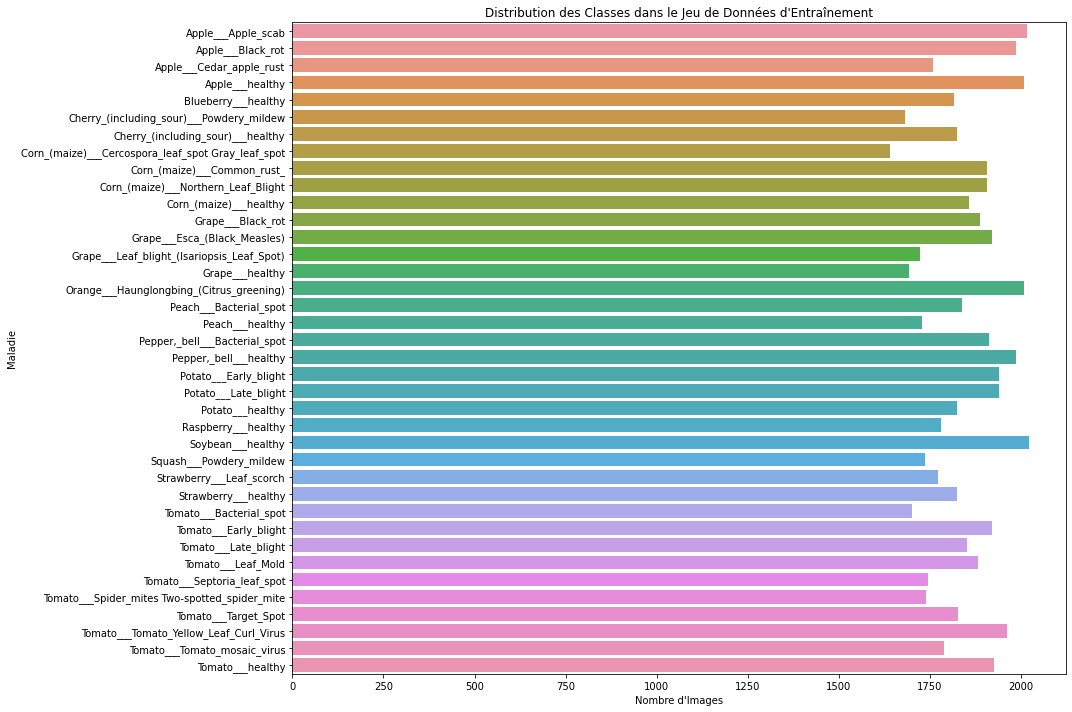

Top 5 des classes avec le plus d'images:
- Pepper,_bell___healthy: 1988 images
- Apple___healthy: 2008 images
- Orange___Haunglongbing_(Citrus_greening): 2010 images
- Apple___Apple_scab: 2016 images
- Soybean___healthy: 2022 images

Top 5 des classes avec le moins d'images:
- Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 images
- Cherry_(including_sour)___Powdery_mildew: 1683 images
- Grape___healthy: 1692 images
- Tomato___Bacterial_spot: 1702 images
- Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1722 images


In [9]:
import seaborn as sns
import os

# Obtenir les noms des classes et le nombre d'images par classe
class_names = list(train_data.class_indices.keys())
class_counts = np.bincount(train_data.classes)

output_dir = ''
# Créer un graphique à barres pour visualiser la distribution
plt.figure(figsize=(15, 10))
sns.barplot(x=class_counts, y=class_names)
plt.title('Distribution des Classes dans le Jeu de Données d\'Entraînement')
plt.xlabel('Nombre d\'Images')
plt.ylabel('Maladie')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'distribution_classes.png'))
plt.show()

# Afficher les 5 classes avec le plus et le moins d'images
print("Top 5 des classes avec le plus d'images:")
for i in np.argsort(class_counts)[-5:]:
    print(f"- {class_names[i]}: {class_counts[i]} images")

print("\nTop 5 des classes avec le moins d'images:")
for i in np.argsort(class_counts)[:5]:
    print(f"- {class_names[i]}: {class_counts[i]} images")

In [ ]:
path='/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
plt.figure(figsize=(70,70))
count=0
plant_names=[]
total_images=0
for i in os.listdir(path):
  count+=1
  plant_names.append(i)
  plt.subplot(7,7,count)

  images_path=os.listdir(path+"/"+i)
  print("Number of images of "+i+":",len(images_path),"||",end=" ")
  total_images+=len(images_path)

  image_show=plt.imread(path+"/"+i+"/"+images_path[0])
  
  plt.imshow(image_show)
  plt.xlabel(i)
  
  plt.xticks([])
  plt.yticks([])


print("Total number of images we have",total_images)


Number of images of Tomato___Late_blight: 1851 || Number of images of Tomato___healthy: 1926 || Number of images of Grape___healthy: 1692 || Number of images of Orange___Haunglongbing_(Citrus_greening): 2010 || Number of images of Soybean___healthy: 2022 || Number of images of Squash___Powdery_mildew: 1736 || Number of images of Potato___healthy: 1824 || Number of images of Corn_(maize)___Northern_Leaf_Blight: 1908 || Number of images of Tomato___Early_blight: 1920 || Number of images of Tomato___Septoria_leaf_spot: 1745 || Number of images of Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 1642 || Number of images of Strawberry___Leaf_scorch: 1774 || Number of images of Peach___healthy: 1728 || Number of images of Apple___Apple_scab: 2016 || Number of images of Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1961 || Number of images of Tomato___Bacterial_spot: 1702 || Number of images of Apple___Black_rot: 1987 || Number of images of Blueberry___healthy: 1816 || Number of images of Cherry

In [23]:
plants = []
NumberOfDiseases = 0
for plant in diseases:
    if plant.split('___')[0] not in plants:
        plants.append(plant.split('___')[0])
    if plant.split('___')[1] != 'healthy':
        NumberOfDiseases += 1

In [24]:
print(f"Unique Plants are: \n{plants}")
print("Number of plants: {}".format(len(plants)))

Unique Plants are: 
['Apple', 'Blueberry', 'Cherry_(including_sour)', 'Corn_(maize)', 'Grape', 'Orange', 'Peach', 'Pepper,_bell', 'Potato', 'Raspberry', 'Soybean', 'Squash', 'Strawberry', 'Tomato']
Number of plants: 14


In [25]:
print("Number of diseases: {}".format(NumberOfDiseases))


Number of diseases: 26


In [26]:
# list of categories in training data
cats = list(train_data.class_indices.keys())

In [27]:
# Augmentations on test data
test_aug = ImageDataGenerator(
    # Rescale
    rescale=1/255.0
)

# Read data from directory
test_data = test_aug.flow_from_directory(
    test_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode="categorical"
)

Found 17572 images belonging to 38 classes.


In [ ]:
# Load the base model
mbnet_v2 = keras.applications.MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=input_shape
)

# Stop from being trainable
mbnet_v2.trainable = True

9412608/9406464 [==============================] - 0s 0us/step


In [ ]:
# Define the layers
inputs = keras.Input(shape=input_shape)

# Get the layer
x = mbnet_v2(inputs, training = True)

# Stack layers further
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.2)(x)
x = tf.keras.layers.Dense(len(cats), activation="softmax")(x)

# Combine the model
model = Model(inputs=inputs, outputs=x)

# Summary
model.summary()

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_2 (InputLayer)         [(None, 256, 256, 3)]     0         
_________________________________________________________________
mobilenetv2_1.00_224 (Functi (None, 8, 8, 1280)        2257984   
_________________________________________________________________
global_average_pooling2d (Gl (None, 1280)              0         
_________________________________________________________________
dropout (Dropout)            (None, 1280)              0         
_________________________________________________________________
dense (Dense)                (None, 38)                48678     
Total params: 2,306,662
Trainable params: 2,272,550
Non-trainable params: 34,112
_________________________________________________________________


In [ ]:
# Compile
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Define callbacks to use
filepath='plant_disease_detection_mobnet.h5'
checkpoint = callbacks.ModelCheckpoint(filepath, monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')
callbacks_list = [checkpoint]

In [ ]:
# Num epochs
epochs = 40

# Train model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=epochs,
    steps_per_epoch=150,
    callbacks=callbacks_list
)

Epoch 1/40
150/150 [==============================] - 269s 2s/step - loss: 1.5908 - accuracy: 0.5683 - val_loss: 0.4859 - val_accuracy: 0.8504

Epoch 00001: val_accuracy improved from -inf to 0.85044, saving model to plant_disease_detection_mobnet.h5
Epoch 2/40
150/150 [==============================] - 155s 1s/step - loss: 0.5447 - accuracy: 0.8407 - val_loss: 0.3314 - val_accuracy: 0.8968

Epoch 00002: val_accuracy improved from 0.85044 to 0.89677, saving model to plant_disease_detection_mobnet.h5
Epoch 3/40
150/150 [==============================] - 154s 1s/step - loss: 0.3569 - accuracy: 0.8889 - val_loss: 0.2265 - val_accuracy: 0.9276

Epoch 00003: val_accuracy improved from 0.89677 to 0.92756, saving model to plant_disease_detection_mobnet.h5
Epoch 4/40
150/150 [==============================] - 154s 1s/step - loss: 0.2703 - accuracy: 0.9098 - val_loss: 0.1984 - val_accuracy: 0.9350

Epoch 00004: val_accuracy improved from 0.92756 to 0.93501, saving model to plant_disease_detecti

In [36]:
modele.evaluate(test_data)

550/550 [==============================] - 69s 123ms/step - loss: 0.0766 - accuracy: 0.9754


[0.07663729041814804, 0.9754154086112976]

## Visualize the model history

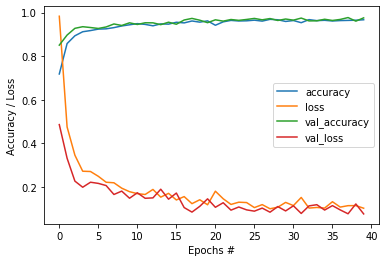

In [ ]:
# Plotting
hist = history.history

# Plot accuracy and loss
plt.plot(hist["accuracy"], label="accuracy")
plt.plot(hist["loss"], label="loss")

if "val_accuracy" in hist and "val_loss" in hist:
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.plot(hist["val_loss"], label="val_loss")

# Add the labels and legend
plt.ylabel("Accuracy / Loss")
plt.xlabel("Epochs #")
plt.legend()

# Finally show the plot
plt.show()

## Save and download the model


In [ ]:
import json

from IPython.display import FileLink

# Link the files
FileLink("./plant_disease_detection_mobnet.h5")

In [21]:
modele = keras.models.load_model('/kaggle/input/plant_disease_detection/tensorflow2/plant_disease_detection/1/plant_disease_detection_mobnet.h5')


In [28]:
predictions = modele.predict(test_data)


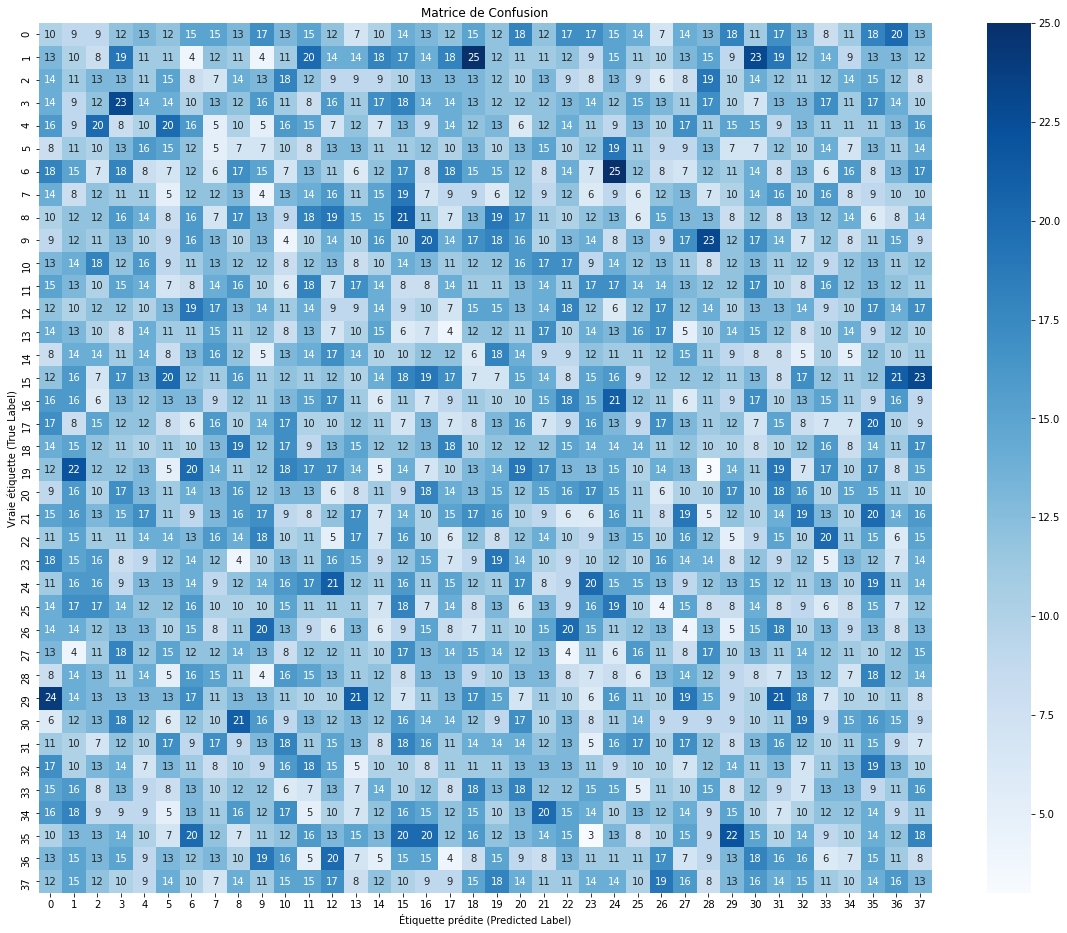

<Figure size 432x288 with 0 Axes>

In [41]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
# Convertir les probabilités en étiquettes de classe prédites
# On prend l'indice de la probabilité la plus élevée comme prédiction
y_pred = np.argmax(predictions, axis=1)

# Obtenir les vraies étiquettes
# Le générateur les garde dans l'attribut '.classes'
y_true = test_data.classes

# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Afficher la matrice de confusion de manière plus jolie (avec Seaborn)
plt.figure(figsize=(20, 16))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de Confusion')
plt.ylabel('Vraie étiquette (True Label)')
plt.xlabel('Étiquette prédite (Predicted Label)')
plt.show()
plt.savefig(os.path.join(output_dir, 'confusion_matrix.png'))

In [37]:
from sklearn.metrics import classification_report

print("Rapport de Classification :\n")
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

Rapport de Classification :

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.02      0.02      0.02       504
                                 Apple___Black_rot       0.02      0.02      0.02       497
                          Apple___Cedar_apple_rust       0.03      0.03      0.03       440
                                   Apple___healthy       0.05      0.05      0.05       502
                               Blueberry___healthy       0.02      0.02      0.02       454
          Cherry_(including_sour)___Powdery_mildew       0.04      0.04      0.04       421
                 Cherry_(including_sour)___healthy       0.02      0.03      0.03       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.03      0.03      0.03       410
                       Corn_(maize)___Common_rust_       0.04      0.04      0.04       477
               Corn_(maize)___Northern_Leaf_Blight

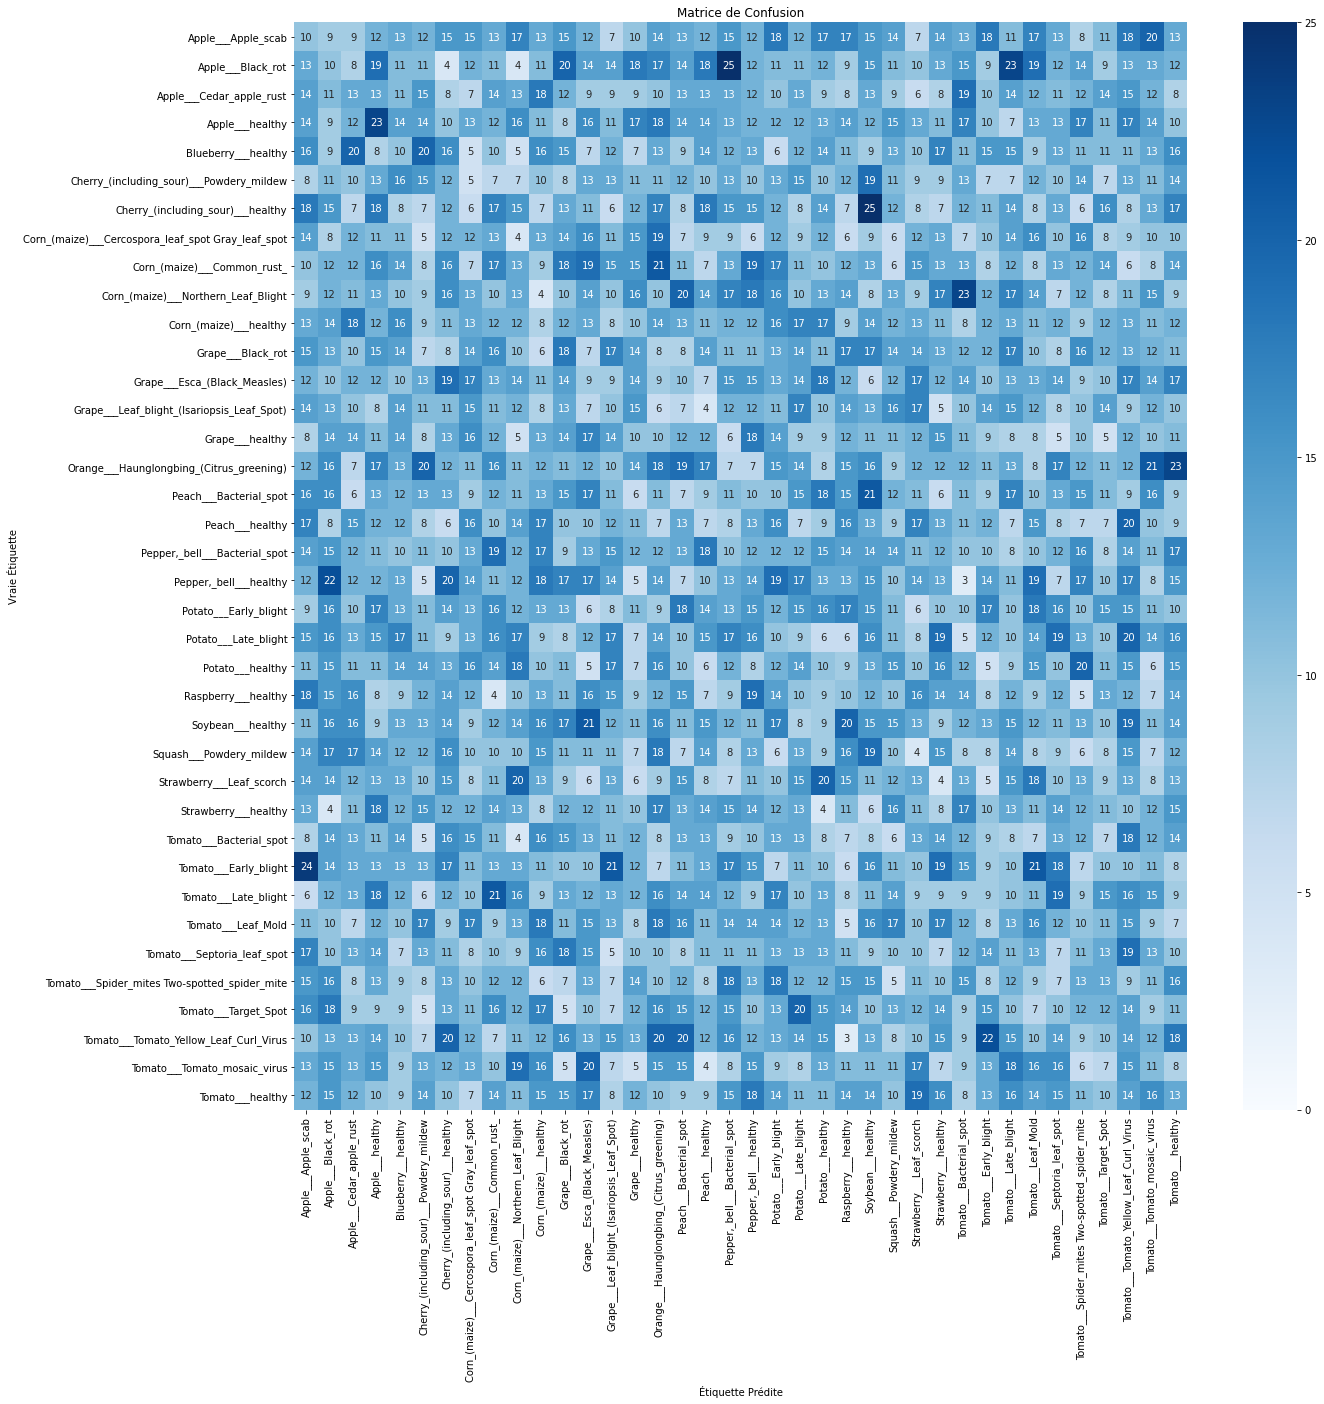

In [45]:

# Calculer la matrice de confusion
cm = confusion_matrix(y_true, y_pred)

# Afficher la matrice de manière visuelle
class_names = diseases

plt.figure(figsize=(20, 20))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Étiquette Prédite")
plt.ylabel("Vraie Étiquette")
plt.title("Matrice de Confusion")
plt.show()